In [1]:
%matplotlib inline
import matplotlib.pyplot as plt


import yaml
import numpy as np

import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

from irc.manager import IRCManager

# Train one agent for a single environment

In [2]:
defaults = {
    'agent.env._target_': 'auditoryforage.AF_env.AuditoryForaging',
    'agent.model._target_': 'irc.model.FuncBeliefModel',
}
manager = IRCManager(defaults=defaults)

## Compare between different environments

In [3]:
from auditoryforage.AF_env import AuditoryForaging

num_epochs = 400
no_episodes = 1000
lick_cost_list = [0]
# food_reward_list = [10.0, 50.0, 100.0, 500.0, 1000.0]
food_reward_list = [10.0, 25.0, 50.0, 75.0, 100.0, 200.0, 300.0, 400.0, 500.0, 600.0, 1000.0]
attention_cost_coeff_list = [.08]
attention_cost_temp_list = [.25]
penalty_cost_list = [0]
iti_cost_list = [0]

total_env_choices = 0

hit_count_list = []
miss_count_list = []
false_alarm_list = []

for lick_cost in lick_cost_list:
    for food_reward in food_reward_list:
        for attention_cost_coeff in attention_cost_coeff_list:
            for attention_cost_temp in attention_cost_temp_list:
                for penalty_cost in penalty_cost_list:
                    for iti_cost in iti_cost_list:
                        env_param = [lick_cost, food_reward, attention_cost_coeff, attention_cost_temp, penalty_cost, iti_cost]
                        env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5]}})
                        agent = manager.train_agent(env_param, num_epochs=num_epochs)
                        hit_count = 0
                        miss_count = 0
                        false_alarm_count = 0
                        for episide_no in range(no_episodes):
                            episode = agent.run_one_episode(env=env, num_steps=10000, q_states = [[i] for i in range(env.no_nodes)])
                            if episode['rewards'][-1] == food_reward:
                                hit_count += 1
                            elif episode['states'][-1] > env.no_signal_nodes + 1:
                                miss_count += 1
                            elif episode['states'][-1] == env.no_signal_nodes + 1:
                                false_alarm_count += 1
                            else:
                                print("Error somewhere")
                        hit_count_list.append(hit_count/no_episodes)
                        miss_count_list.append(miss_count/no_episodes)
                        false_alarm_list.append(false_alarm_count/no_episodes)
                        total_env_choices += 1

/Users/lokeshboominathan/miniconda3/envs/IRC/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Checkpoint (epoch 400) loaded.
Checkpoint (epoch 400) loaded.
Checkpoint (epoch 400) loaded.
Checkpoint (epoch 400) loaded.
Checkpoint (epoch 400) loaded.
Checkpoint (epoch 400) loaded.
Checkpoint (epoch 400) loaded.
Checkpoint (epoch 400) loaded.
Checkpoint (epoch 400) loaded.
Checkpoint (epoch 400) loaded.
Checkpoint (epoch 400) loaded.


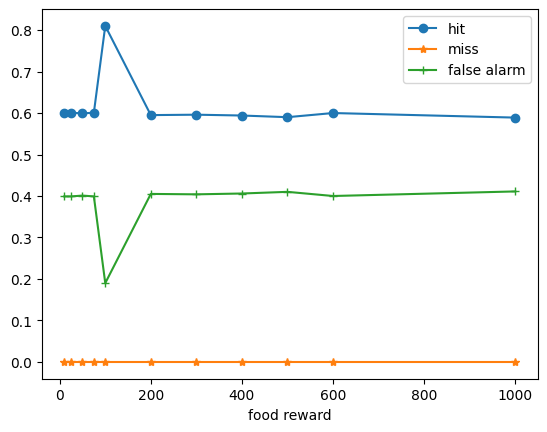

In [4]:
plt.plot(food_reward_list, hit_count_list, 'o-')
plt.plot(food_reward_list, miss_count_list, '-*')
plt.plot(food_reward_list, false_alarm_list, '-+')
plt.legend(['hit', 'miss', 'false alarm'])
plt.xlabel('food reward')
plt.show()